# X-axis line detection with OpenCV

In this notebook the **x-axsis line** of a bar chart is being detected with **OpenCV**

De stappen zijn:

1. Afbeelding inladen
2. Afbeelding omzetten naar grayscale
3. Canny edge detection toepassen
4. Rechte lijnen detecteren met Hough Line Transform
5. Alleen horizontale lijnen filteren
6. De meest waarschijnlijke x-as kiezen
7. Resultaat opslaan

## 1. Imports

Installeer eerst de packages als dat nog niet is gedaan:

```bash
pip install opencv-python matplotlib numpy
```

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Zorg dat plots netjes in de notebook verschijnen
%matplotlib inline

## 2. Pad naar de afbeelding

In [16]:
IMAGE_PATH = Path("../Dataset/Compliant/10.png")

# Output map
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Image path:", IMAGE_PATH)
print("Bestand bestaat:", IMAGE_PATH.exists())

Image path: ..\Dataset\Compliant\10.png
Bestand bestaat: True


## 3. Afbeelding inladen en tonen

Hier laden we de afbeelding in met OpenCV. OpenCV leest afbeeldingen standaard in als BGR, daarom zetten we hem voor matplotlib om naar RGB.

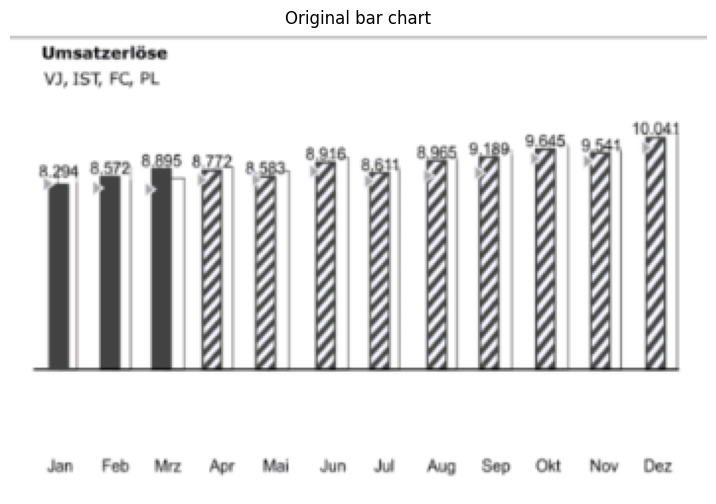

In [17]:
image = cv2.imread(str(IMAGE_PATH))

if image is None:
    raise FileNotFoundError(
        f"Afbeelding niet gevonden: {IMAGE_PATH}. Pas IMAGE_PATH aan naar jouw bestand."
    )

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title("Original bar chart")
plt.axis("off")
plt.show()

## 4. Grayscale

Voor edge detection is kleur niet nodig. Daarom zetten we de afbeelding om naar grayscale.

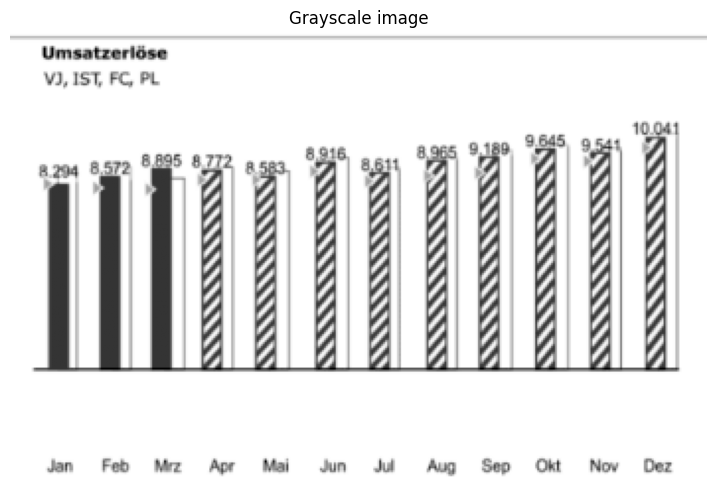

In [18]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

## 5. Edge detection met Canny

Canny edge detection zoekt duidelijke randen in de afbeelding. De x-as lijn wordt hierdoor vaak zichtbaar als een rand/lijn.

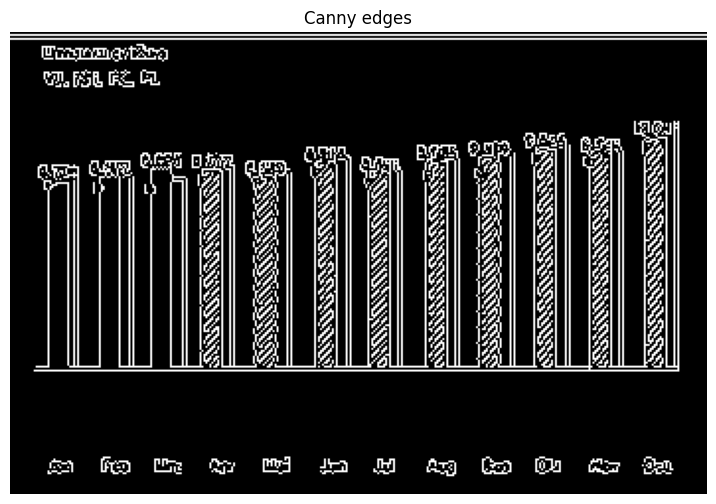

In [19]:
# Je kunt deze waarden aanpassen als de detectie niet goed werkt
LOW_THRESHOLD = 50
HIGH_THRESHOLD = 150

edges = cv2.Canny(gray, LOW_THRESHOLD, HIGH_THRESHOLD)

plt.figure(figsize=(10, 6))
plt.imshow(edges, cmap="gray")
plt.title("Canny edges")
plt.axis("off")
plt.show()

## 6. Lijnen detecteren met Hough Line Transform

Met `cv2.HoughLinesP` zoeken we rechte lijnen in de edge-afbeelding.

In [20]:
# Parameters die je eventueel kunt tunen
HOUGH_THRESHOLD = 80
MIN_LINE_LENGTH = 100
MAX_LINE_GAP = 10

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=HOUGH_THRESHOLD,
    minLineLength=MIN_LINE_LENGTH,
    maxLineGap=MAX_LINE_GAP
)

print("Aantal gevonden lijnen:", 0 if lines is None else len(lines))

Aantal gevonden lijnen: 41


## 7. Alle gevonden lijnen visualiseren

Dit helpt om te controleren welke lijnen OpenCV heeft gevonden.

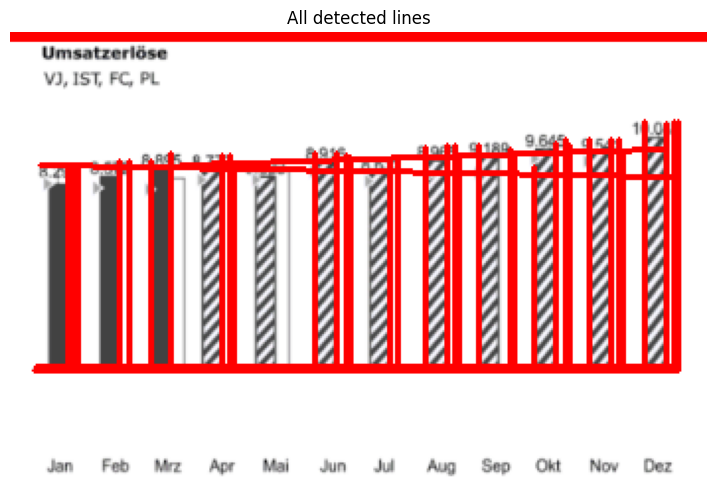

In [21]:
all_lines_image = image_rgb.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(all_lines_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(all_lines_image)
plt.title("All detected lines")
plt.axis("off")
plt.show()

## 8. Horizontale lijnen filteren

De x-as is meestal een lange horizontale lijn. Daarom houden we alleen lijnen over waarbij het verschil tussen `y1` en `y2` klein is.

In [22]:
horizontal_lines = []

# Hoe kleiner deze waarde, hoe strenger de lijn horizontaal moet zijn
HORIZONTAL_TOLERANCE = 5

# Minimale lengte van een x-as lijn
MIN_X_AXIS_LENGTH = 100

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        
        is_horizontal = abs(y2 - y1) <= HORIZONTAL_TOLERANCE
        is_long_enough = length >= MIN_X_AXIS_LENGTH
        
        if is_horizontal and is_long_enough:
            horizontal_lines.append((x1, y1, x2, y2, length))

print("Aantal horizontale lijnen:", len(horizontal_lines))
horizontal_lines[:10]

Aantal horizontale lijnen: 4


[(np.int32(0), np.int32(3), np.int32(352), np.int32(3), np.float64(352.0)),
 (np.int32(0), np.int32(1), np.int32(352), np.int32(1), np.float64(352.0)),
 (np.int32(12),
  np.int32(171),
  np.int32(338),
  np.int32(171),
  np.float64(326.0)),
 (np.int32(13),
  np.int32(169),
  np.int32(338),
  np.int32(169),
  np.float64(325.0))]

## 9. Horizontale lijnen tonen

Hier zie je alleen de lijnen die als horizontaal zijn gefilterd.

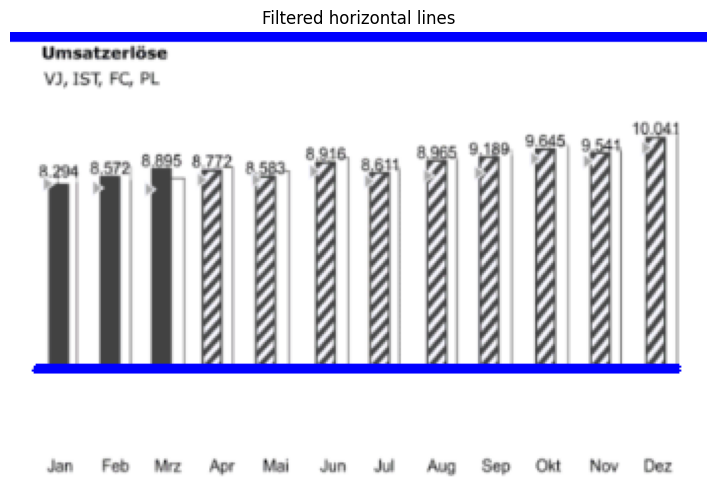

In [23]:
horizontal_image = image_rgb.copy()

for x1, y1, x2, y2, length in horizontal_lines:
    cv2.line(horizontal_image, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(horizontal_image)
plt.title("Filtered horizontal lines")
plt.axis("off")
plt.show()

## 10. X-as lijn kiezen

Een simpele regel is: **kies de laagste lange horizontale lijn**.  
Bij een standaard bar chart ligt de x-as meestal onderaan de plot area.

In [24]:
if len(horizontal_lines) == 0:
    raise ValueError("Geen horizontale lijn gevonden. Probeer de parameters aan te passen.")

# Kies de lijn met de grootste y-waarde, dus de laagste horizontale lijn
x_axis_line = max(horizontal_lines, key=lambda line: max(line[1], line[3]))

x1, y1, x2, y2, length = x_axis_line

print("Detected x-axis line:")
print("x1:", x1)
print("y1:", y1)
print("x2:", x2)
print("y2:", y2)
print("length:", round(length, 2))

Detected x-axis line:
x1: 12
y1: 171
x2: 338
y2: 171
length: 326.0


## 11. Eindresultaat tonen

De gedetecteerde x-as wordt groen getekend.

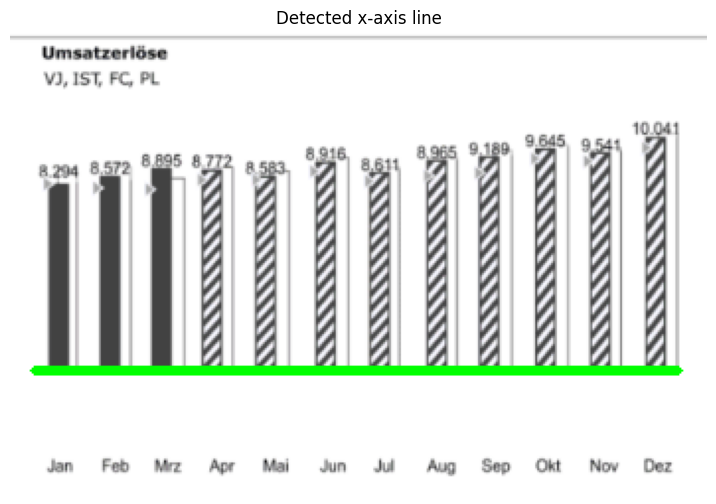

In [25]:
result_image = image_rgb.copy()
cv2.line(result_image, (x1, y1), (x2, y2), (0, 255, 0), 4)

plt.figure(figsize=(10, 6))
plt.imshow(result_image)
plt.title("Detected x-axis line")
plt.axis("off")
plt.show()

## 12. Resultaat opslaan

De afbeelding met de gedetecteerde x-as wordt opgeslagen in de output-map.

In [26]:
output_path = OUTPUT_DIR / f"x_axis_detected_{IMAGE_PATH.name}"

# Convert RGB back to BGR before saving with OpenCV
result_bgr = cv2.cvtColor(result_image, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(output_path), result_bgr)

print("Resultaat opgeslagen als:", output_path)

Resultaat opgeslagen als: ..\output\x_axis_detected_10.png


## 13. Functie maken voor hergebruik

Hier maken we dezelfde logica als functie, zodat je meerdere afbeeldingen kunt testen.

In [27]:
def detect_x_axis_line(image_path, output_dir="../output", show=True):
    """
    Detecteert de meest waarschijnlijke x-as lijn in een bar chart image.
    
    Returns:
        dict met x1, y1, x2, y2, length en output_path
    """
    image_path = Path(image_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Afbeelding niet gevonden: {image_path}")
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=100,
        maxLineGap=10
    )
    
    horizontal_lines = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
            if abs(y2 - y1) <= 5 and length >= 100:
                horizontal_lines.append((x1, y1, x2, y2, length))
    
    if len(horizontal_lines) == 0:
        return {
            "image": str(image_path),
            "found": False,
            "message": "No horizontal x-axis line found."
        }
    
    x_axis_line = max(horizontal_lines, key=lambda line: max(line[1], line[3]))
    x1, y1, x2, y2, length = x_axis_line
    
    result_image = image_rgb.copy()
    cv2.line(result_image, (x1, y1), (x2, y2), (0, 255, 0), 4)
    
    output_path = output_dir / f"x_axis_detected_{image_path.name}"
    result_bgr = cv2.cvtColor(result_image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(output_path), result_bgr)
    
    if show:
        plt.figure(figsize=(10, 6))
        plt.imshow(result_image)
        plt.title(f"Detected x-axis: {image_path.name}")
        plt.axis("off")
        plt.show()
    
    return {
        "image": str(image_path),
        "found": True,
        "x1": int(x1),
        "y1": int(y1),
        "x2": int(x2),
        "y2": int(y2),
        "length": float(length),
        "output_path": str(output_path)
    }

## 14. Test de functie op één afbeelding

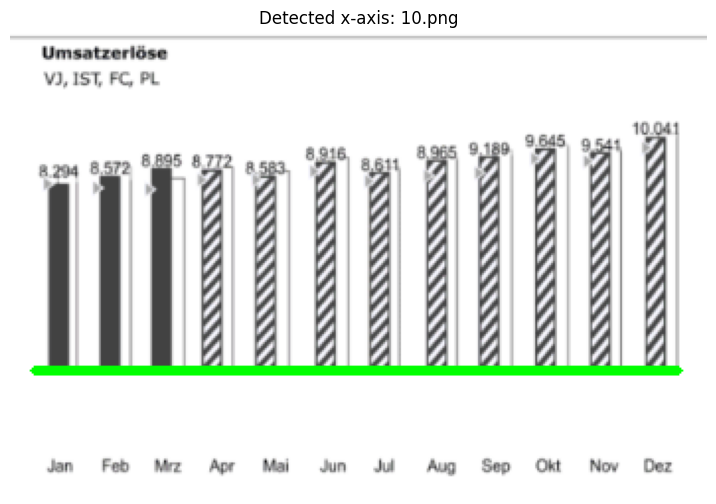

{'image': '..\\Dataset\\Compliant\\10.png',
 'found': True,
 'x1': 12,
 'y1': 171,
 'x2': 338,
 'y2': 171,
 'length': 326.0,
 'output_path': '..\\output\\x_axis_detected_10.png'}

In [28]:
result = detect_x_axis_line(IMAGE_PATH, output_dir=OUTPUT_DIR, show=True)
result

## 15. Meerdere afbeeldingen testen

Als je meerdere afbeeldingen in `Dataset/Compliant` of `Dataset/Non-Compliant` hebt staan, kun je ze automatisch testen.

In [29]:
# Kies welke map je wilt testen
TEST_FOLDER = Path("../Dataset/Compliant")

image_extensions = ["*.png", "*.jpg", "*.jpeg"]
image_files = []
for ext in image_extensions:
    image_files.extend(TEST_FOLDER.glob(ext))

print("Aantal afbeeldingen gevonden:", len(image_files))

results = []
for img_path in image_files:
    try:
        res = detect_x_axis_line(img_path, output_dir=OUTPUT_DIR, show=False)
        results.append(res)
    except Exception as e:
        results.append({"image": str(img_path), "found": False, "message": str(e)})

results[:5]

Aantal afbeeldingen gevonden: 105


[{'image': '..\\Dataset\\Compliant\\10.png',
  'found': True,
  'x1': 12,
  'y1': 171,
  'x2': 338,
  'y2': 171,
  'length': 326.0,
  'output_path': '..\\output\\x_axis_detected_10.png'},
 {'image': '..\\Dataset\\Compliant\\100.png',
  'found': True,
  'x1': 345,
  'y1': 599,
  'x2': 971,
  'y2': 599,
  'length': 626.0,
  'output_path': '..\\output\\x_axis_detected_100.png'},
 {'image': '..\\Dataset\\Compliant\\101.png',
  'found': True,
  'x1': 174,
  'y1': 428,
  'x2': 279,
  'y2': 428,
  'length': 105.0,
  'output_path': '..\\output\\x_axis_detected_101.png'},
 {'image': '..\\Dataset\\Compliant\\102.png',
  'found': True,
  'x1': 73,
  'y1': 603,
  'x2': 331,
  'y2': 603,
  'length': 258.0,
  'output_path': '..\\output\\x_axis_detected_102.png'},
 {'image': '..\\Dataset\\Compliant\\103.png',
  'found': True,
  'x1': 73,
  'y1': 259,
  'x2': 457,
  'y2': 259,
  'length': 384.0,
  'output_path': '..\\output\\x_axis_detected_103.png'}]

## 16. Korte uitleg voor je verslag

Je kunt dit gebruiken in je documentatie:

> This project uses an OpenCV-based computer vision pipeline to detect the x-axis line in bar chart images. First, the image is converted to grayscale. Then, Canny edge detection is used to identify strong edges in the chart. After that, the Hough Line Transform is applied to detect straight lines. Because the x-axis is usually a long horizontal line near the bottom of the chart, the detected lines are filtered based on orientation and length. Finally, the lowest long horizontal line is selected as the x-axis line.

Limitatie:

> This approach works best when the x-axis line is clearly visible. It may be less accurate when the chart contains many gridlines, when the x-axis is missing, or when the image quality is low.